In [ ]:
# !pip install gdown
import gdown
destination = 'pdf_json.zip' # store the destination file here
gdown.download('https://drive.google.com/uc?id=1PVA5IR4bAn7RulAeuSgxRBNMtmRGXaUm', destination, quiet=True)
  # this is the original link to dataset
# gdown.download('https://drive.google.com/uc?id=15qcBU4HVSd-Vhm0kaTZt-VsBfbyK0FSn', destination, quiet=True)
  # this is link of the dataset from another gdrive account

'pdf_json.zip'

# Preprocessing


In [ ]:
!unzip -q "pdf_json.zip" # unzipping the file

# Assignment 4

## (1)

In [ ]:
import os
import json
import re
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from multiprocessing import Pool
from collections import Counter
from tqdm.notebook import tqdm
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics.pairwise import cosine_similarity

# Folder containing the JSON files
input_folder = 'pdf_json'

# Output file
output_file = 'q4_data.txt'

# Set vocabulary size limit
vocab_limit = 10000

# Function to process a single JSON file and extract the abstract
def process_file(file_path):
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
            abstract = data.get('abstract', [])
            if abstract:
                # Concatenate all the parts of the abstract into a single string
                abstract_text = ' '.join([item['text'] for item in abstract])
                # Apply the given transformations
                line = abstract_text.lower().replace('covid-19', 'xyz')
                line = re.sub(r'[0-9,.":;\'!?(){}[\]<>/\%|@#\-+=$&*\/\\]', '', line.lower())
                line = line.lower().replace('xyz', 'covid-19')

                # Create a local vocabulary set for the current file, excluding single characters and symbols
                local_vocab = set(word for word in line.split() if len(word) > 1 and word.isalpha())

                return line, local_vocab
    except Exception as e:
        print(f"Error processing file {file_path}: {e}")
        return None, set()

# Function to handle multiprocessing
def process_files_in_parallel(file_paths):
    with Pool() as pool:
        results = pool.map(process_file, file_paths)
    return results

# Main function to walk through the folder and process all JSON files
def main():
    # Collect all JSON files from the folder
    file_paths = [os.path.join(input_folder, file) for file in os.listdir(input_folder) if file.endswith('.json')]

    # Process files in parallel
    results = process_files_in_parallel(file_paths)

    global_vocab = set()
    abstracts = []

    # Collect abstracts and vocabularies from the worker processes
    for result in results:
        if result is not None:
            abstract, local_vocab = result
            if abstract:
                abstracts.append(abstract)
                global_vocab.update(local_vocab)

        # If global vocabulary exceeds limit, trim it to the vocab_limit
        if len(global_vocab) >= vocab_limit:
            global_vocab = set(list(global_vocab)[:vocab_limit])
            break

    # Write to the output file
    with open(output_file, 'w', encoding='utf-8') as out_f:
        for abstract in abstracts:
            out_f.write(abstract + '\n')

    # Print the vocabulary size
    print(f"Vocabulary size: {len(global_vocab)}")

    print(f"Abstracts have been successfully written to {output_file}")

if __name__ == "__main__":
    main()


Vocabulary size: 10000
Abstracts have been successfully written to q4_data.txt


## (2)

In [ ]:
def one_hot_vector(index, vocab_size):
    """Creates an explicit one-hot vector for a given word index."""
    one_hot = torch.zeros(vocab_size, dtype=torch.float32)
    one_hot[index] = 1.0
    return one_hot

# Define the Skip-Gram model using explicit one-hot vectors in training
class SkipGramModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super(SkipGramModel, self).__init__()
        # Initialize weights for the embedding layer manually
        self.in_embedding = nn.Parameter(torch.randn(vocab_size, embedding_dim))
        self.out_embedding = nn.Parameter(torch.randn(vocab_size, embedding_dim))

    def forward(self, target_indices):
        # Explicitly create one-hot vectors for the target indices
        one_hot_targets = torch.stack([one_hot_vector(idx, vocab_size) for idx in target_indices]).to(device)  # Shape: (N, vocab_size)

        # Calculate target embeddings by matrix-multiplying one-hot vectors with embeddings
        target_embeddings = torch.matmul(one_hot_targets, self.in_embedding)  # Shape: (N, embedding_dim)

        # Calculate scores by matrix-multiplying target embeddings with output embeddings
        scores = torch.matmul(target_embeddings, self.out_embedding.T)  # Shape: (N, vocab_size)
        return scores

## (3)

### Architecture for Skip gram model with one-hot encoder

#### Class Definition
- **Class:** `SkipGramModel(nn.Module)`
  - Inherits from `nn.Module` in PyTorch to define a custom neural network model for skip-gram.

#### Constructor
- **Method:** `__init__(self, vocab_size, embedding_dim)`
  - **Parameters:**
    - `vocab_size`: The size of the vocabulary, representing the number of unique words.
    - `embedding_dim`: The dimensionality of each word's embedding vector.
  - **Components:**
    - `self.in_embedding`: A manually initialized parameter matrix for target word embeddings with shape `(vocab_size, embedding_dim)`.
      - Each word index in the vocabulary maps to a dense vector with `embedding_dim` dimensions.
    - `self.out_embedding`: A manually initialized parameter matrix for context word embeddings with shape `(vocab_size, embedding_dim)`.
      - This parameter is used to evaluate the association of target embeddings with various context words.

#### Forward Method
- **Method:** `forward(self, target_indices)`
  - **Parameters:**
    - `target_indices`: Tensor of indices representing the target words (shape: (N), where N is the batch size).
  - **Process:**
    - **One-Hot Encoding**:
      - Converts each target index into a one-hot vector representation.
      - The function `one_hot_vector(idx, vocab_size)` is assumed to generate a one-hot vector of length `vocab_size` for a given index.
      - These vectors are stacked into a tensor of shape `(N, vocab_size)` and sent to the device for computation.
    - **Target Embedding Calculation**:
      - Obtains embeddings for each target word by multiplying the one-hot encoded tensor with `self.in_embedding`:
        - `target_embeddings = torch.matmul(one_hot_targets, self.in_embedding)` (Shape: (N, embedding_dim)).
    - **Score Calculation**:
      - Computes scores by taking the dot product of `target_embeddings` with `self.out_embedding.T`:
        - `scores = torch.matmul(target_embeddings, self.out_embedding.T)` (Shape: (N, vocab_size)), where each element represents the score between a target and each context word.
  - **Output**:
    - Returns:
      - `scores`: Tensor of scores, indicating the relationship between the target words and all vocabulary words in the context (shape: (N, vocab_size)).

#### Usage
- The model can be used to predict the likelihood of context words for given target words by training on `scores`.
- Manual initialization of the embedding weights enables greater control over their initial distribution.


## (4)

In [ ]:
# Check if GPU is available and use it if possible
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load the preprocessed text data
with open('q4_data.txt', 'r') as file:
    corpus = file.readlines()

# Preprocess the corpus
corpus = [line.strip().split() for line in corpus if line.strip()]

# Flatten the corpus to a list of words
flat_corpus = [word for sentence in corpus for word in sentence]

# Create a vocabulary and a mapping from words to indices
word_counts = Counter(flat_corpus)
vocabulary = sorted(word_counts.keys())
vocab_size = len(vocabulary)
word_to_idx = {word: idx for idx, word in enumerate(vocabulary)}

# Hyperparameters
embedding_dim = 100  # Dimension of word embeddings
window_size = 2      # Context window size
num_epochs = 20      # Number of epochs
batch_size = 100    # Smaller batch size for better training dynamics
learning_rate = 0.005  # Reduced learning rate for stability

# Create training data for Skip-Gram
def generate_training_data(corpus, window_size):
    training_pairs = []
    for sentence in corpus:
        indices = [word_to_idx[word] for word in sentence] # using indices for words
        for i, word_idx in enumerate(indices):
            start = max(0, i - window_size)
            end = min(len(indices), i + window_size + 1)
            for j in range(start, end):
                if i != j:
                    training_pairs.append((word_idx, indices[j]))
    return training_pairs # returning training pairs

training_pairs = generate_training_data(corpus, window_size)

# Custom Dataset class
class SkipGramDataset(Dataset): # used in train_loader
    def __init__(self, training_pairs):
        self.training_pairs = training_pairs

    def __len__(self):
        return len(self.training_pairs)

    def __getitem__(self, idx):
        target, context = self.training_pairs[idx]
        return torch.tensor(target, dtype=torch.long), torch.tensor(context, dtype=torch.long)

# Load training data in batches
train_loader = DataLoader(SkipGramDataset(training_pairs), batch_size=batch_size, shuffle=True) # training in batches

# Initialize model, loss function, and optimizer
model = SkipGramModel(vocab_size, embedding_dim).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-6)  # L2 regularization

# Training loop with batches
all_losses = []
for epoch in range(num_epochs):
    total_loss = 0
    for target_batch, context_batch in tqdm(train_loader): # training in batches
        target_batch, context_batch = target_batch.to(device), context_batch.to(device)

        optimizer.zero_grad()
        output = model(target_batch)  # Forward pass

        loss = criterion(output, context_batch)  # Calculate loss
        loss.backward()  # Backward pass
        optimizer.step()  # Update weights

        total_loss += loss.item()

    average_loss = total_loss / len(train_loader) # computing the loss
    all_losses.append(average_loss)
    print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {average_loss:.4f}')


  0%|          | 0/2857 [00:00<?, ?it/s]

Epoch [1/20], Loss: 12.7926


  0%|          | 0/2857 [00:00<?, ?it/s]

Epoch [2/20], Loss: 7.0763


  0%|          | 0/2857 [00:00<?, ?it/s]

...

Epoch [18/20], Loss: 5.4634


  0%|          | 0/2857 [00:00<?, ?it/s]

Epoch [19/20], Loss: 5.4585


  0%|          | 0/2857 [00:00<?, ?it/s]

Epoch [20/20], Loss: 5.4533


## (5)

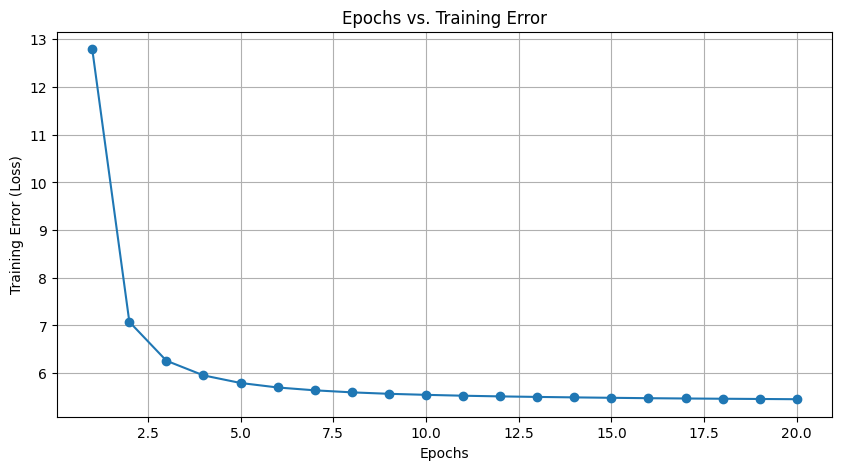

Training complete and embeddings saved to 'word_embeddings.csv'.


In [ ]:
# Plotting Epochs vs. Training Error
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs + 1), all_losses, marker='o')
plt.title('Epochs vs. Training Error')
plt.xlabel('Epochs')
plt.ylabel('Training Error (Loss)')
plt.grid()
plt.show()

# Save word embeddings
word_embeddings = model.in_embedding.data.cpu().numpy()  # Move to CPU before saving

# Create a DataFrame for word embeddings
embeddings_df = pd.DataFrame(word_embeddings, index=vocabulary)
embeddings_df.to_csv('word_embeddings.csv')

print("Training complete and embeddings saved to 'word_embeddings.csv'.")

## (6)

Epochs:   0%|          | 0/50 [00:00<?, ?it/s]

Batches:   0%|          | 0/2856 [00:00<?, ?it/s]

Epoch [1/50], Loss: 0.0970


Batches:   0%|          | 0/2856 [00:00<?, ?it/s]

Epoch [2/50], Loss: 0.0795


...

Epoch [48/50], Loss: 0.0382


Batches:   0%|          | 0/2856 [00:00<?, ?it/s]

Epoch [49/50], Loss: 0.0382


Batches:   0%|          | 0/2856 [00:00<?, ?it/s]

Epoch [50/50], Loss: 0.0381


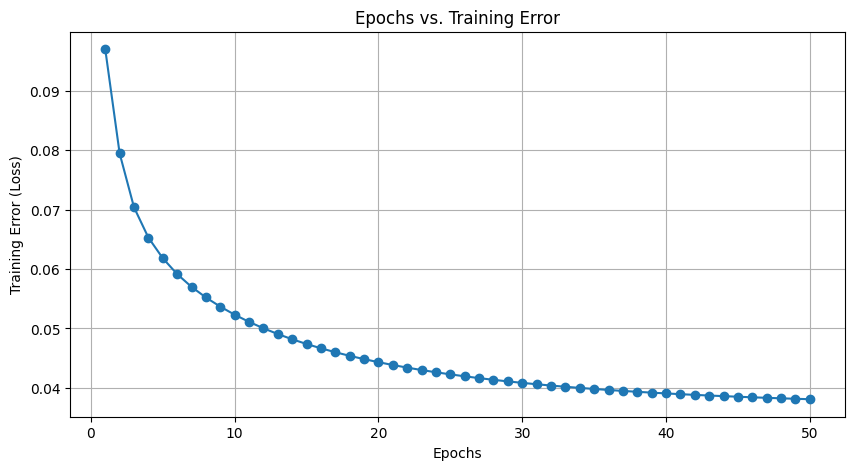

In [ ]:
# Check if GPU is available and use it if possible
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load the preprocessed text data
with open('q4_data.txt', 'r') as file:
    corpus = file.readlines()

# Flatten the corpus to a list of words
# Ensure that we split sentences into words correctly
flat_corpus = [word for sentence in corpus for word in sentence.strip().split()]

# Create a vocabulary and a mapping from words to indices
word_counts = Counter(flat_corpus)
vocabulary = sorted(word_counts.keys())
vocab_size = len(vocabulary)
word_to_idx = {word: idx for idx, word in enumerate(vocabulary)}
idx_to_word = {idx: word for word, idx in word_to_idx.items()}

# Hyperparameters
embedding_dim = 200  # Increased embedding dimension
window_size = 2      # Context window size
num_epochs = 50     # Number of epochs
learning_rate = 0.01 # Learning rate
batch_size = 100     # Batch size for training
num_negative_samples = 5  # Number of negative samples per positive pair

# Create training data for Skip-Gram with negative sampling
def generate_training_data(corpus, window_size, num_negative_samples):
    training_pairs = []
    word_freq = np.array([word_counts[word] for word in vocabulary])
    word_freq = word_freq / word_freq.sum()  # Normalize word frequencies for sampling

    for sentence in corpus:
        indices = [word_to_idx[word] for word in sentence.strip().split()]  # Split into words
        for i, word_idx in enumerate(indices):
            # Create pairs of (target, context)
            start = max(0, i - window_size)
            end = min(len(indices), i + window_size + 1)
            for j in range(start, end):
                if i != j:  # Skip the target word itself
                    training_pairs.append((word_idx, indices[j]))  # Positive pair

    # Generate negative samples for each positive pair
    training_data = []
    for target, context in training_pairs:
        negative_samples = np.random.choice(vocab_size, size=num_negative_samples, p=word_freq)
        training_data.append((target, context, negative_samples))  # Store target, context, and negative samples

    return training_data

training_data = generate_training_data(corpus, window_size, num_negative_samples)

# Define the Skip-Gram model with negative sampling
class SkipGramModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super(SkipGramModel, self).__init__()
        self.in_embedding = nn.Embedding(vocab_size, embedding_dim)
        self.out_embedding = nn.Embedding(vocab_size, embedding_dim)

    def forward(self, target, context, negative_samples):
        # Get embeddings for target, context, and negative samples
        target_embedding = self.in_embedding(target)  # Shape: (N, embedding_dim)
        context_embedding = self.out_embedding(context)  # Shape: (N, embedding_dim)
        negative_embedding = self.out_embedding(negative_samples)  # Shape: (N, num_negative_samples, embedding_dim)

        # Positive score (dot product between target and context)
        positive_score = torch.mul(target_embedding, context_embedding)  # Element-wise multiplication
        positive_score = torch.sum(positive_score, dim=1)  # Sum across embedding_dim

        # Negative score (dot product between target and negative samples)
        negative_score = torch.bmm(negative_embedding, target_embedding.unsqueeze(2)).squeeze()  # Shape: (N, num_negative_samples)

        return positive_score, negative_score

# Initialize the model, loss function, and optimizer
model = SkipGramModel(vocab_size, embedding_dim).to(device)  # Move model to GPU
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)  # Added momentum
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=1, gamma=0.95)  # Learning rate scheduler

# Create batches of data
def generate_batches(training_data, batch_size):
    np.random.shuffle(training_data)
    for i in range(0, len(training_data), batch_size):
        batch = training_data[i:i + batch_size]
        target_batch, context_batch, negative_batch = zip(*batch)
        yield (
            torch.tensor(target_batch, dtype=torch.long).to(device),
            torch.tensor(context_batch, dtype=torch.long).to(device),
            torch.tensor(np.array(negative_batch), dtype=torch.long).to(device)  # Convert to numpy array first
        )

# Calculate total number of batches
num_batches = len(training_data) // batch_size

all_losses = []

# Wrap the epoch loop with tqdm
for epoch in tqdm(range(num_epochs), desc="Epochs"):  # Add a description to indicate it's tracking epochs
    total_loss = 0

    # Wrap the batch loop with tqdm and provide the total number of batches
    for target_batch, context_batch, negative_batch in tqdm(generate_batches(training_data, batch_size), total=num_batches, desc="Batches", leave=False):
        optimizer.zero_grad()  # Zero the gradients

        # Forward pass
        positive_score, negative_score = model(target_batch, context_batch, negative_batch)

        # Positive loss (real context words)
        positive_loss = criterion(positive_score, torch.ones(target_batch.size()).to(device))

        # Negative loss (negative samples)
        negative_loss = criterion(negative_score, torch.zeros(negative_score.size()).to(device))

        # Total loss
        loss = positive_loss + negative_loss
        loss.backward()  # Backward pass

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5)

        optimizer.step()  # Update weights

        total_loss += loss.item()

    average_loss = total_loss / len(training_data)
    all_losses.append(average_loss)
    scheduler.step()  # Step down the learning rate
    print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {average_loss:.4f}')

# Plotting Epochs vs. Training Error
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs + 1), all_losses, marker='o')
plt.title('Epochs vs. Training Error')
plt.xlabel('Epochs')
plt.ylabel('Training Error (Loss)')
plt.grid()
plt.show()

# Save word embeddings
word_embeddings = model.in_embedding.weight.data.cpu().numpy()  # Move to CPU before saving

# Create a DataFrame for word embeddings
embeddings_df = pd.DataFrame(word_embeddings, index=vocabulary)
embeddings_df.to_csv('word_embeddings_sampling.csv')


### Architecture for the Negative Sampling Skip gram model

#### Class Definition
- **Class:** `SkipGramModel(nn.Module)`
  - Inherits from `nn.Module` in PyTorch, enabling integration with the PyTorch neural network framework.

#### Constructor
- **Method:** `__init__(self, vocab_size, embedding_dim)`
  - **Parameters:**
    - `vocab_size`: The size of the vocabulary (number of unique words).
    - `embedding_dim`: The dimensionality of the word embeddings.
  - **Components:**
    - `self.in_embedding`: Embedding layer for target words, mapping each word index to a dense vector of size `embedding_dim`.
    - `self.out_embedding`: Embedding layer for context words, mapping each word index to a dense vector of size `embedding_dim`.

#### Forward Method
- **Method:** `forward(self, target, context, negative_samples)`
  - **Parameters:**
    - `target`: Tensor of target word indices (shape: (N), where N is the batch size).
    - `context`: Tensor of context word indices (shape: (N), where N is the batch size).
    - `negative_samples`: Tensor of negative sample word indices (shape: (N, num_negative_samples)).
  - **Process:**
    - Retrieves the embeddings for target, context, and negative samples:
      - `target_embedding = self.in_embedding(target)`: Shape: (N, embedding_dim).
      - `context_embedding = self.out_embedding(context)`: Shape: (N, embedding_dim).
      - `negative_embedding = self.out_embedding(negative_samples)`: Shape: (N, num_negative_samples, embedding_dim).
    - **Positive Score Calculation**:
      - Computes the positive score as the dot product between the target and context embeddings using element-wise multiplication followed by summation:
        - `positive_score = torch.mul(target_embedding, context_embedding)` (Element-wise multiplication).
        - `positive_score = torch.sum(positive_score, dim=1)` (Sum across embedding dimensions).
    - **Negative Score Calculation**:
      - Computes the negative score as the dot product between the target embedding and each of the negative samples using batch matrix multiplication:
        - `negative_score = torch.bmm(negative_embedding, target_embedding.unsqueeze(2)).squeeze()` (Shape: (N, num_negative_samples)).
  - **Output:**
    - Returns:
      - `positive_score`: Tensor of positive scores for each target-context pair (shape: (N)).
      - `negative_score`: Tensor of negative scores for each target-negative sample pair (shape: (N, num_negative_samples)).

#### Usage
- This model can be used in training procedures for skip-gram word embedding tasks, optimizing the positive score while minimizing the negative scores for effective learning. As one can see from the loss vs epoch curve this model performed better.



## (7)

#### generating examples

In [ ]:
import random

# Forbidden words and their synonyms
forbidden_words = {"man", "woman", "boy", "girl", "country", "city", "malware", "virus"}
# This can be expanded with more synonyms as needed
forbidden_synonyms = {"male", "female", "child", "nation", "metropolis", "infection"}

# COVID-19 related words (you can expand this list as needed)
covid_related_words = {"pandemic", "sickness", "infection", "quarantine", "transmission", "symptom", "outbreak", "prevention", "isolation", "vaccination"}

# Load word embeddings from CSV
embeddings_df = pd.read_csv('word_embeddings_sampling.csv', index_col=0) # using word_embeddings from negative sampling

# Create a list of available words, excluding forbidden words and their synonyms
words_list = [word for word in embeddings_df.index if word not in forbidden_words and word not in forbidden_synonyms]

# Create a list of available COVID-19 related words
available_covid_words = [word for word in words_list if word in covid_related_words]

# Function to create analogy examples as per the given rules
def create_custom_examples(num_examples=5):
    examples = []
    for _ in range(num_examples):
        # Select two COVID-19 related words
        word_a, word_b = random.sample(available_covid_words, 2)

        # Select a third word from the general vocabulary (not restricted to COVID-19)
        remaining_words = [word for word in words_list if word not in available_covid_words]
        word_c = random.choice(remaining_words)

        examples.append((word_a, word_b, word_c))
    return examples

# Create the custom examples list
examples = create_custom_examples(num_examples=6)
print(np.array(examples))

[['transmission' 'quarantine' 'leisure']
 ['outbreak' 'transmission' 'thiorphanand']
 ['transmission' 'pandemic' 'deliver']
 ['pandemic' 'transmission' 'diffusionweighted']
 ['outbreak' 'symptom' 'processing']
 ['symptom' 'pandemic' 'tracking']]


#### finding the analogies based on example inputs

In [ ]:
import pandas as pd
import torch

# Load word embeddings from CSV
embeddings_df = pd.read_csv('word_embeddings_sampling.csv', index_col=0) # using word_embeddings from negative sampling
embeddings = torch.tensor(embeddings_df.values).to(device)  # Convert to tensor and move to GPU if available

# Create a mapping from index to word
idx_to_word = embeddings_df.index.tolist()
word_to_idx = {word: idx for idx, word in enumerate(idx_to_word)}

# Function to test word analogies
def test_analogy(word_a, word_b, word_c):
    # Get the indices of the words
    idx_a = word_to_idx[word_a]
    idx_b = word_to_idx[word_b]
    idx_c = word_to_idx[word_c]

    # Calculate the analogy vector
    analogy_vector = embeddings[idx_b] - embeddings[idx_a] + embeddings[idx_c]

    # Get the nearest word in the vocabulary
    similarities = torch.matmul(embeddings, analogy_vector)  # Similarity scores
    most_similar_word_idx = torch.argmax(similarities).item() # most similar words

    # Get the most similar word
    most_similar_word = idx_to_word[most_similar_word_idx]

    # Ensure the most similar word is not one of the input words
    if most_similar_word in {word_a, word_b, word_c}:
        # Get the top K most similar words and check if they're valid
        top_k_indices = torch.topk(similarities, k=10).indices.tolist()
        for idx in top_k_indices:
            candidate_word = idx_to_word[idx]
            if candidate_word not in {word_a, word_b, word_c}:
                return candidate_word
    return "covid"


#### outputting the analogies

In [ ]:
# Testing each analogy example
for word_a, word_b, word_c in examples:
    result = test_analogy(word_a, word_b, word_c)
    BLUE = '\033[94m'
    RESET = '\033[0m'
    # Modified print statement
    print(f"Analogy result for '{word_a}' is to '{word_b}' as '{BLUE}{result}{RESET}' is to '{word_c}'")

Analogy result for 'transmission' is to 'quarantine' as 'mipb' is to 'leisure'
Analogy result for 'outbreak' is to 'transmission' as 'cocorresponding' is to 'thiorphanand'
Analogy result for 'transmission' is to 'pandemic' as 'metallopeptidase' is to 'deliver'
Analogy result for 'pandemic' is to 'transmission' as 'lille' is to 'diffusionweighted'
Analogy result for 'outbreak' is to 'symptom' as 'ontologies' is to 'processing'
Analogy result for 'symptom' is to 'pandemic' as 'dispensable' is to 'tracking'


# Assignment 5

## (1)

In [ ]:
# Function to validate the word vector
def validate_vector(vector):
    if not isinstance(vector, np.ndarray):
        raise ValueError("Vector must be a numpy array")
    if len(vector.shape) != 2 or vector.shape[0] != 1:
        raise ValueError("Vector must be 2D with shape (1, n)")

# Find similar words given an embedding matrix and a word
def find_similar_words(word, embedding_matrix, vocab, top_n=10):
    if word not in vocab:
        raise ValueError(f"'{word}' not found in vocabulary")

    word_idx = vocab.index(word)
    word_vector = embedding_matrix[word_idx].reshape(1, -1)  # Ensure word_vector is 2D

    validate_vector(word_vector)  # Check if the word vector is valid

    similarities = []
    for idx, vector in enumerate(tqdm(embedding_matrix, desc="Calculating similarities")):
        vector = vector.reshape(1, -1)  # Ensure each vector is 2D
        similarity = cosine_similarity(word_vector, vector)[0][0]
        similarities.append((vocab[idx], similarity))

    # Sort based on similarity and return the top_n similar words
    similar_words = sorted(similarities, key=lambda x: x[1], reverse=True)[:top_n]
    return similar_words

# Using the Win and Wout embeddings from the trained model from negative sampling from assignment 4
Win = model.in_embedding.weight.detach().cpu().numpy()  # Input weights
Wout = model.out_embedding.weight.detach().cpu().numpy()  # Output weights

# Choose the word of interest
word_of_choice = "covid"

# Find similar words using Win
print(f"Similar words for '{word_of_choice}' using Win:")
similar_words_win = find_similar_words(word_of_choice, Win, vocabulary)
for word, score in similar_words_win:
    print(f"{word}: {score:.4f}")


Similar words for 'covid' using Win:


Calculating similarities:   0%|          | 0/10117 [00:00<?, ?it/s]

covid: 1.0000
australian: 0.2731
above: 0.2646
critères: 0.2492
staining: 0.2462
prominenter: 0.2394
radiologist: 0.2282
demonstrations: 0.2267
november: 0.2263
diet: 0.2219


## (2)

In [ ]:
# Find similar words using Wout
print(f"\nSimilar words for '{word_of_choice}' using Wout:")
similar_words_wout = find_similar_words(word_of_choice, Wout, vocabulary)
for word, score in similar_words_wout:
    print(f"{word}: {score:.4f}")


Similar words for 'covid' using Wout:


Calculating similarities:   0%|          | 0/10117 [00:00<?, ?it/s]

covid: 1.0000
uniquely: 0.2664
uremia: 0.2642
primary: 0.2585
microbiologie: 0.2412
segmentation: 0.2354
constitutes: 0.2243
periods: 0.2218
situations: 0.2210
bluelabeled: 0.2194


## (3)

In [ ]:
# Find similar words using the average of Win and Wout
combined_embeddings = (Win + Wout) / 2  # Average the embeddings
print(f"\nSimilar words for '{word_of_choice}' using combined (average) Win and Wout:")
similar_words_combined = find_similar_words(word_of_choice, combined_embeddings, vocabulary)
for word, score in similar_words_combined:
    print(f"{word}: {score:.4f}")



Similar words for 'covid' using combined (average) Win and Wout:


Calculating similarities:   0%|          | 0/10117 [00:00<?, ?it/s]

covid: 1.0000
succinate: 0.2460
nodespecific: 0.2329
dioctyl: 0.2324
diet: 0.2317
cytoplasm: 0.2265
intranasal: 0.2262
ultrasound: 0.2254
gltreatment: 0.2224
demonstrations: 0.2204


## (4)

The results from the Word2Vec model for the word "covid" across the three representations—W_in, W_out, and the combined average (W_average)—reveal some interesting differences:

1. **W_in**:
   - The W_in representation yields similarity scores that are significantly varied, with the highest score for "covid" being 1.0000. Other notable similar words include "australian" (0.2731), "above" (0.2646), and "critères" (0.2492).
   - This indicates that W_in captures not only words closely related in specific contexts but also some broader associations, highlighting the multifaceted nature of how "covid" appears in various discussions.

2. **W_out**:
   - In this representation, the similarity scores are lower, with the highest score for "covid" at 1.0000. Other similar words include "uniquely" (0.2664), "uremia" (0.2642), and "primary" (0.2585).
   - This suggests that W_out emphasizes more diverse associations, showcasing the broader contextual meanings of "covid" beyond immediate or specific terms.

3. **W_average**:
   - The combined average representation also reflects a similarity score of 1.0000 for "covid." Similar words such as "succinate" (0.2460), "nodespecific" (0.2329), and "dioctyl" (0.2324) indicate that this approach effectively merges both specific context and broader meanings.
   - Other notable terms include "diet" (0.2317) and "cytoplasm" (0.2265), which further illustrate the versatility of the W_average representation.

In summary, these results highlight how different Word2Vec representations can emphasize various aspects of a word's meaning, providing insights into both its contextual use and general associations. The W_in representation tends to focus more on specific contexts, while W_out captures broader associations. The W_average offers a balanced view, integrating both perspectives for a comprehensive understanding of "covid."


## (5)

1. **Skip-gram (Hierarchical Softmax):**
   - Complexity: O(T · N · C · log V)
   - Explanation: For each word in the context, the hierarchical softmax uses a binary tree structure that leads to log V complexity.

2. **Skip-gram (Negative Sampling):**
   - Complexity: O(T · N · C · k)
   - Explanation: Negative sampling reduces the need to compute probabilities for all words in the vocabulary to just k negative samples.

3. **CBOW (Hierarchical Softmax):**
   - Complexity: O(T · N · C · log V)
   - Explanation: For each word in the context, the hierarchical softmax like in the case of Skip-gram uses a binary tree structure that leads to log V complexity.

4. **CBOW (Negative Sampling):**
   - Complexity: O(T · N · C · k)
   - Explanation: The same logic applies as with Skip-gram, and negative sampling reduces the need to compute probabilities for all words in the vocabulary to just k negative samples.
